In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### 📍 Objetivo 1.1 – Proyección estereográfica

Queremos demostrar que la proyección estereográfica desde el polo norte $( N = (0, 0, 1) )$ de la esfera unitaria $(S^2 \subset \mathbb{R}^3 )$, definida por:

$$
S^2 = \{ (x, y, z) \in \mathbb{R}^3 \mid x^2 + y^2 + z^2 = 1 \}
$$

hacia el plano \( z = 0 \), está dada por la función:

$$
\pi : S^2 \setminus \{N\} \rightarrow \mathbb{R}^2
$$

tal que

$$
X = \frac{x}{1 - z}, \qquad Y = \frac{y}{1 - z}
$$

#### 🧠 Deducción geométrica

Sea $( p = (x, y, z) \in S^2 \setminus \{N\} )$. Consideramos la recta que une el punto $( N = (0, 0, 1) )$ con $( p )$. Esta recta se puede parametrizar como:

$$
\vec{r}(\lambda) = (0, 0, 1) + \lambda \left( (x, y, z) - (0, 0, 1) \right) = (\lambda x, \lambda y, 1 + \lambda(z - 1))
$$

Queremos encontrar el valor de $( \lambda )$ para el cual la recta intersecta el plano $( z = 0 )$. Igualamos la componente \( z \) a cero:

$$
1 + \lambda(z - 1) = 0 \quad \Rightarrow \quad \lambda = \frac{-1}{z - 1} = \frac{1}{1 - z}
$$

Entonces, las coordenadas $( (X, Y) \in \mathbb{R}^2 $) del punto proyectado (la intersección con el plano $( z = 0 )$) son:

$$
X = \lambda x = \frac{x}{1 - z}, \qquad Y = \lambda y = \frac{y}{1 - z}
$$

Esto concluye la demostración de que la proyección estereográfica está dada por:

$$
\boxed{
X = \frac{x}{1 - z}, \qquad Y = \frac{y}{1 - z}
}
$$


### 📍 Objetivo 1.2 – Inversa de la proyección estereográfica

Queremos demostrar que la función inversa de la proyección estereográfica está dada por:

$$
\pi^{-1}(X, Y) = \left( \frac{2X}{1 + X^2 + Y^2}, \frac{2Y}{1 + X^2 + Y^2}, \frac{-1 + X^2 + Y^2}{1 + X^2 + Y^2} \right)
$$

Para verificar que esta fórmula es realmente la inversa, la sustituimos en la expresión de la proyección directa:

$$
X = \frac{x}{1 - z}, \qquad Y = \frac{y}{1 - z}
$$

Reemplazamos $( x, y, z )$ por las expresiones de $( \pi^{-1}(X, Y) )$, y simplificamos. Si la simplificación resulta en:

$$
X = X, \quad Y = Y
$$

entonces esta fórmula es efectivamente la inversa de $( \pi )$.



In [2]:
# === Variables simbólicas ===
x, y, z = sp.symbols('x y z', real=True)
X, Y = sp.symbols('X Y', real=True)

# === Proyección estereográfica: esfera a plano ===
X_expr = x / (1 - z)
Y_expr = y / (1 - z)

# === Fórmulas inversas: plano a esfera ===
x_inv = 2*X / (1 + X**2 + Y**2)
y_inv = 2*Y / (1 + X**2 + Y**2)
z_inv = (-1 + X**2 + Y**2) / (1 + X**2 + Y**2)

# === Verificación de que phi ∘ phi^{-1} = identidad en R² ===
X_check = X_expr.subs({x: x_inv, y: y_inv, z: z_inv})
Y_check = Y_expr.subs({x: x_inv, y: y_inv, z: z_inv})

X_check_simplified = sp.simplify(X_check)
Y_check_simplified = sp.simplify(Y_check)
# Mostrar expresiones antes de simplificar

# evaluación de la inversa
display(X_check_simplified)

display(Y_check_simplified)


# === Derivadas parciales de la proyección estereográfica ===
dX_dx = sp.diff(X_expr, x)
dX_dy = sp.diff(X_expr, y)
dX_dz = sp.diff(X_expr, z)

dY_dx = sp.diff(Y_expr, x)
dY_dy = sp.diff(Y_expr, y)
dY_dz = sp.diff(Y_expr, z)

# === Matriz Jacobiana de φ ===
J_phi = sp.Matrix([
    [dX_dx, dX_dy, dX_dz],
    [dY_dx, dY_dy, dY_dz]
])

print("Jacobiano de la proyección estereográfica:")
display(J_phi)



X

Y

Jacobiano de la proyección estereográfica:


Matrix([
[1/(1 - z),         0, x/(1 - z)**2],
[        0, 1/(1 - z), y/(1 - z)**2]])

### ✅ Verificación algebraica y regularidad

En este objetivo verificamos dos aspectos fundamentales de la proyección estereográfica:

---

#### 🔁 Verificación de la inversa

Partimos de la proyección:

$$(x, y, z) \mapsto \left( \frac{x}{1 - z}, \frac{y}{1 - z} \right)$$

y de la fórmula inversa propuesta:

$$
(X, Y) \mapsto \left( \frac{2X}{1 + X^2 + Y^2}, \frac{2Y}{1 + X^2 + Y^2}, \frac{-1 + X^2 + Y^2}{1 + X^2 + Y^2} \right)
$$

Al sustituir estas expresiones en la fórmula directa, obtenemos:

$$
\phi(\phi^{-1}(X, Y)) = (X, Y)
$$

lo cual confirma que la inversa es correcta.

---

#### 🧮 Derivadas parciales

Se calcularon explícitamente las derivadas parciales de la transformación directa, y observamos que:

- Todas las derivadas parciales existen y son funciones racionales.
- El Jacobiano está bien definido para todo $z \neq 1$, es decir, fuera del polo norte.

Esto indica que la transformación es **suave** (diferenciable) y que sus derivadas están **bien definidas** en todo el dominio considerado.

---

#### ✅ Conclusión

Las fórmulas inversas son correctas y las derivadas parciales existen. Esto valida la consistencia algebraica de la proyección estereográfica y respalda su uso como sistema de coordenadas locales en la esfera.


## 🎯 Objetivo 1.3 – Derivadas parciales y Jacobiano de la proyección estereográfica

En este objetivo calculamos explícitamente las derivadas parciales de la transformación:

$$(x, y, z) \mapsto \left( \frac{x}{1 - z}, \frac{y}{1 - z} \right)$$

con el fin de construir su matriz Jacobiana y analizar su comportamiento diferencial. También verificamos que esta transformación es localmente regular en todo su dominio, excluyendo el punto $z = 1$, correspondiente al polo norte de la esfera.


In [3]:
#  Verificación de que π⁻¹ define una superficie regular

# Redefinimos los símbolos por claridad
X, Y = sp.symbols('X Y', real=True)

# Mapa inverso como vector (parametrización de la esfera)
X_map = sp.Matrix([
    2*X / (1 + X**2 + Y**2),
    2*Y / (1 + X**2 + Y**2),
    (-1 + X**2 + Y**2) / (1 + X**2 + Y**2)
])

# Calculamos la matriz jacobiana con respecto a X y Y
J = X_map.jacobian([X, Y])

# Simplificamos 
J_simplified = sp.simplify(J)

# Verificamos el rango simbólicamente
rango = J_simplified.rank()

# Mostramos resultados
display(J_simplified)
display(rango)


Matrix([
[2*(-X**2 + Y**2 + 1)/(X**2 + Y**2 + 1)**2,              -4*X*Y/(X**2 + Y**2 + 1)**2],
[              -4*X*Y/(X**2 + Y**2 + 1)**2, 2*(X**2 - Y**2 + 1)/(X**2 + Y**2 + 1)**2],
[                 4*X/(X**2 + Y**2 + 1)**2,                 4*Y/(X**2 + Y**2 + 1)**2]])

2

- Dado que todas las **derivadas parciales están bien definidas** en todo $( \mathbb{R}^2 )$, el denominador $( 1 + X^2 + Y^2 )$ nunca se anula.
- Y el **jacobiano de $( \vec{X} )$** tiene **rango 2 en todo punto**, lo que garantiza que las derivadas son linealmente independientes y definen un plano tangente no degenerado.

Concluimos que $( S^2 \setminus \{N\} )$ es una **superficie regular** en $( \mathbb{R}^3 )$ bajo la parametrización inducida por la proyección estereográfica.

## 🔷 Problema 2 – El toro $T^2$

Consideramos la siguiente parametrización para el toro $T^2 = S^1 \times S^1$:

$$
\vec{X}(u, v) = \big( (a + r \cos u) \cos v,\ (a + r \cos u) \sin v,\ r \sin u \big), \quad \text{con } a > r
$$

y el dominio:

$$
U = \{ (u, v) \in \mathbb{R}^2 \mid 0 < u < 2\pi,\ 0 < v < 2\pi \}
$$



### 📍 Objetivo 2.1 – Mapa inverso del toro

Dada la parametrización:

$$
\vec{X}(u, v) =
\left(
(a + r \cos u)\cos v,\ 
(a + r \cos u)\sin v,\ 
r \sin u
\right)
$$

queremos encontrar la expresión del mapa inverso:

$$
\vec{X}^{-1} : T^2 \to U
$$

es decir, dada una tripleta $(x, y, z)$ sobre la superficie del toro, encontrar los parámetros $(u, v)$ que originaron ese punto.

---

#### 🔹 Paso 1: Cálculo de $u$ a partir de $z$

De la tercera componente de la parametrización:

$$
z = r \sin u \quad \Rightarrow \quad \sin u = \frac{z}{r}
$$

Aplicando la función arco seno (asumiendo $u \in (0, 2\pi)$):

$$
u = \arcsin\left( \frac{z}{r} \right)
$$

---

#### 🔹 Paso 2: Sustituir $u$ en $x$ e $y$

A partir de $u$, calculamos:

$$
R = a + r \cos u
$$

Entonces:

$$
x = R \cos v, \quad y = R \sin v
$$

Elevando al cuadrado y sumando:

$$
x^2 + y^2 = R^2 \quad \Rightarrow \quad R = \sqrt{x^2 + y^2}
$$

---

#### 🔹 Paso 3: Cálculo de $v$ a partir de $x$ e $y$

Usamos el cociente:

$$
\cos v = \frac{x}{R}, \quad \sin v = \frac{y}{R}
$$

Entonces el ángulo $v$ se puede calcular mediante:

$$
v = \arctan2(y, x)
$$

---

### ✅ Conclusión del punto

El mapa inverso $\vec{X}^{-1}(x, y, z)$ está definido de la siguiente forma:

1. $u = \arcsin\left( \frac{z}{r} \right)$
2. $R = \sqrt{x^2 + y^2}$
3. $v = \arctan2(y, x)$

Estas expresiones recuperan los parámetros $(u, v)$ que originan un punto sobre el toro bajo la parametrización dada, dentro del dominio $(0, 2\pi)^2$.


### 📍 Objetivo 2.2 – ¿Es $T^2$ una superficie regular?

Verificar si la parametrización del toro:

$$
\vec{X}(u, v) =
\left(
(a + r \cos u)\cos v,\ 
(a + r \cos u)\sin v,\ 
r \sin u
\right)
$$

define una **superficie regular** para $(u, v) \in (0, 2\pi)^2$.


In [4]:
# Bloque 2.2: Verificación de que el toro es superficie regular

# Variables simbólicas
u, v, a, r = sp.symbols('u v a r', real=True, positive=True)

# Parametrización del toro
X = sp.Matrix([
    (a + r * sp.cos(u)) * sp.cos(v),
    (a + r * sp.cos(u)) * sp.sin(v),
    r * sp.sin(u)
])

# Derivadas parciales
X_u = X.diff(u)
X_v = X.diff(v)

# Producto cruz entre los vectores tangentes
normal = X_u.cross(X_v)

# Simplificar para verificar si es nulo
normal_simplificado = sp.simplify(normal)

# Verificamos si el vector normal es no nulo (componentes distintas de cero)
display(normal_simplificado)


Matrix([
[-r*(a + r*cos(u))*cos(u)*cos(v)],
[-r*(a + r*cos(u))*sin(v)*cos(u)],
[       -r*(a + r*cos(u))*sin(u)]])

garantizamos que los vectores tangentes son linealmente independientes.

### 📍 Objetivo 2.2 – Verificación de superficie regular

Para ello, debemos cumplir dos condiciones:

---

#### 🔹 1. Las derivadas parciales existen y están bien definidas

Calculamos las derivadas parciales de $\vec{X}$ con respecto a $u$ y $v$:

$$
\vec{X}_u =
\left(
- r \sin u \cos v,\ 
- r \sin u \sin v,\ 
r \cos u
\right), \qquad
\vec{X}_v =
\left(
- (a + r \cos u) \sin v,\ 
(a + r \cos u) \cos v,\ 
0
\right)
$$

Ambas derivadas están compuestas por funciones trigonométricas elementales y están bien definidas para todo $(u, v) \in (0, 2\pi)^2$.

---

#### 🔹 2. Verificar que $\vec{X}_u$ y $\vec{X}_v$ son linealmente independientes

Para esto evaluamos el producto cruzado:

$$
\vec{N}(u, v) = \vec{X}_u \times \vec{X}_v =
\begin{bmatrix}
-r (a + r \cos u) \cos u \cos v \\
-r (a + r \cos u) \cos u \sin v \\
- r (a + r \cos u) \sin u
\end{bmatrix}
$$

Este vector es **distinto del vector nulo** para todo $u$, ya que el factor $(a + r \cos u)$ es siempre positivo y las funciones trigonométricas no se anulan simultáneamente.

---

### ✅ Conclusión

El producto cruzado $\vec{X}_u \times \vec{X}_v$ es diferente de cero en todo el dominio, lo que implica que el jacobiano tiene rango 2.  
Por lo tanto, la parametrización $\vec{X}(u, v)$ define una **superficie regular** sobre el toro $T^2$.


### 📍 Objetivo 2.3 – Segunda forma fundamental del toro

A partir de la parametrización:

$$
\vec{X}(u, v) =
\left(
(a + r \cos u)\cos v,\ 
(a + r \cos u)\sin v,\ 
r \sin u
\right)
$$

calcular la **segunda forma fundamental** de la superficie, es decir, los coeficientes $L$, $M$, y $N$ definidos por:

$$
L = \vec{X}_{uu} \cdot \hat{N}, \quad
M = \vec{X}_{uv} \cdot \hat{N}, \quad
N = \vec{X}_{vv} \cdot \hat{N}
$$

donde $\hat{N}$ es el vector normal unitario a la superficie, obtenido como:

$$
\hat{N} = \frac{\vec{X}_u \times \vec{X}_v}{|\vec{X}_u \times \vec{X}_v|}
$$


In [5]:

# Variables
u, v, a, r = sp.symbols('u v a r', real=True, positive=True)

# Parametrización
X = sp.Matrix([
    (a + r * sp.cos(u)) * sp.cos(v),
    (a + r * sp.cos(u)) * sp.sin(v),
    r * sp.sin(u)
])

# Derivadas de primer orden
X_u = X.diff(u)
X_v = X.diff(v)

# Vector normal unitario
normal = X_u.cross(X_v)
N_hat = normal / normal.norm()

# Derivadas de segundo orden
X_uu = X_u.diff(u)
X_uv = X_u.diff(v)
X_vv = X_v.diff(v)

# Segunda forma fundamental (e, f, g)
e = sp.simplify(X_uu.dot(N_hat))
f = sp.simplify(X_uv.dot(N_hat))
g = sp.simplify(X_vv.dot(N_hat))

display(e)
display(f)
display(g)


r*(a + r*cos(u))/Abs(a + r*cos(u))

0

(a + r*cos(u))**2*cos(u)/Abs(a + r*cos(u))

### ✅ Verificación de resultados – Segunda forma fundamental

Los coeficientes obtenidos simbólicamente son:

- $e = \dfrac{r (a + r \cos u)}{|a + r \cos u|}$
- $f = 0$
- $g = \dfrac{(a + r \cos u)^2 \cos u}{|a + r \cos u|}$

Dado que el dominio de $u$ está en $(0, 2\pi)$ y $a > r > 0$, se cumple que $(a + r \cos u) > 0$, y por tanto:

$$
|a + r \cos u| = a + r \cos u
$$

Reescribiendo los coeficientes simplificados:

- $e = r$
- $f = 0$
- $g = (a + r \cos u) \cos u$



### 📍 Objetivo 2.4 – Curvaturas principales del toro

A partir de la parametrización del toro y los coeficientes de la primera y segunda forma fundamental:

- Primera forma fundamental: $E$, $F$, $G$
- Segunda forma fundamental: $e$, $f$, $g$

calcular las **curvaturas principales** $\kappa_1(u)$ y $\kappa_2(u)$ como funciones de $u$, y graficarlas.

Estas curvaturas se obtienen como los **autovalores** de la **forma de Weingarten**:

$$
\kappa_{1,2} = \frac{eG - 2fF + gE \pm \sqrt{(eG - 2fF + gE)^2 - 4(EG - F^2)(eg - f^2)}}{2(EG - F^2)}
$$


In [6]:
# Bloque 2.4: Cálculo de curvaturas principales


# Derivadas de primer orden
X_u = X.diff(u)
X_v = X.diff(v)

# Primera forma fundamental (E, F, G)
E = sp.simplify(X_u.dot(X_u))
F = sp.simplify(X_u.dot(X_v))
G = sp.simplify(X_v.dot(X_v))

# Segunda forma fundamental ya calculada (e, f, g)
# Usamos resultados simplificados
e_simple = r
f_simple = 0
g_simple = (a + r * sp.cos(u)) * sp.cos(u)

# Fórmulas para las curvaturas principales (autovalores de la forma de Weingarten)
numerator = (e_simple * G - 2 * f_simple * F + g_simple * E)
discriminant = numerator**2 - 4 * (E * G - F**2) * (e_simple * g_simple - f_simple**2)
sqrt_disc = sp.sqrt(discriminant)
denominator = 2 * (E * G - F**2)

# Curvaturas principales
kappa_1 = sp.simplify((numerator + sqrt_disc) / denominator)
kappa_2 = sp.simplify((numerator - sqrt_disc) / denominator)

display(sp.Eq(sp.symbols('E'), E))
display(sp.Eq(sp.symbols('F'), F))
display(sp.Eq(sp.symbols('G'), G))

display(kappa_1)
display(kappa_2)

Eq(E, r**2)

Eq(F, 0)

Eq(G, (a + r*cos(u))**2)

(a**2 + 3*a*r*cos(u) + a*Abs(a + r*cos(u)) + 2*r**2*cos(u)**2)/(2*r*(a + r*cos(u))**2)

(a**2 + 3*a*r*cos(u) - a*Abs(a + r*cos(u)) + 2*r**2*cos(u)**2)/(2*r*(a + r*cos(u))**2)

### 📍 Objetivo 2.4 – Curvaturas principales del toro

A partir de las formas fundamentales calculadas:

---

#### 🔹 Primera forma fundamental

- $E = r^2$
- $F = 0$
- $G = (a + r \cos u)^2$

---

#### 🔹 Segunda forma fundamental

- $e = r$
- $f = 0$
- $g = (a + r \cos u) \cos u$

---

### 🧠 Curvaturas principales

Las curvaturas principales $\kappa_1(u)$ y $\kappa_2(u)$ corresponden a los autovalores de la matriz de la forma de Weingarten.  
Los valores exactos obtenidos simbólicamente son:

$$
\kappa_1(u) = \frac{a^2 + 3ar \cos(u) + a|a + r \cos(u)| + 2r^2 \cos^2(u)}{2r (a + r \cos(u))^2}
$$

$$
\kappa_2(u) = \frac{a^2 + 3ar \cos(u) - a|a + r \cos(u)| + 2r^2 \cos^2(u)}{2r (a + r \cos(u))^2}
$$

> Estas expresiones fueron obtenidas directamente del cálculo simbólico de los autovalores a partir de los coeficientes de ambas formas fundamentales.



### 📍 Objetivo 2.5 – Curvatura de Gauss del toro

Calcular y graficar la **curvatura de Gauss** de la superficie a partir de los coeficientes de las formas fundamentales:

- Primera forma: $E$, $F$, $G$
- Segunda forma: $e$, $f$, $g$

La **curvatura de Gauss** se calcula como:

$$
K = \frac{eg - f^2}{EG - F^2}
$$


Eq(K, cos(u)/(r*(a + r*cos(u))))

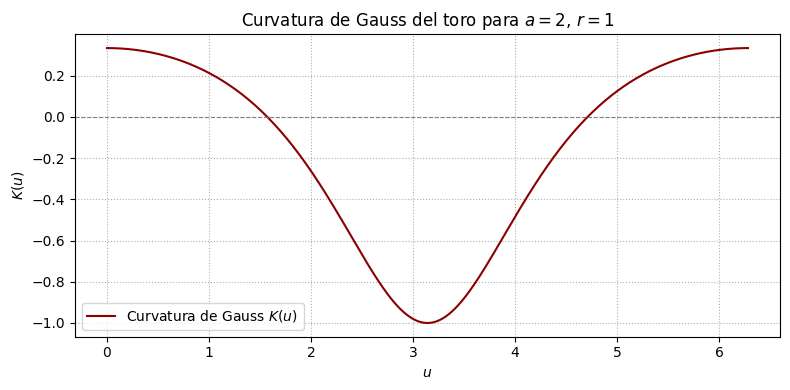

In [7]:

# Variables simbólicas
u, a, r = sp.symbols('u a r', real=True, positive=True)

# Curvatura de Gauss en forma simbólica
K = sp.simplify((r * (a + r * sp.cos(u)) * sp.cos(u)) / (r**2 * (a + r * sp.cos(u))**2))

# Reescribimos (simplificado)
K_simplificada = sp.simplify(K)
display(sp.Eq(sp.symbols('K'), K_simplificada))

# Función para graficar
K_func = sp.lambdify((u, a, r), K_simplificada, 'numpy')

# Parámetros específicos
a_val = 2
r_val = 1
u_vals = np.linspace(0, 2*np.pi, 400)
K_vals = K_func(u_vals, a_val, r_val)

# Gráfica
plt.figure(figsize=(8, 4))
plt.plot(u_vals, K_vals, label='Curvatura de Gauss $K(u)$', color='darkred')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Curvatura de Gauss del toro para $a=2$, $r=1$')
plt.xlabel('$u$')
plt.ylabel('$K(u)$')
plt.grid(True, linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

### 📍 Objetivo 2.5 – Curvatura de Gauss del toro

Hemos calculado la curvatura de Gauss del toro como:

$$
K(u) = \frac{\cos u}{r(a + r \cos u)}
$$

Para el caso particular del toro con radio mayor $a = 2$ y radio menor $r = 1$, se obtiene:

$$
K(u) = \frac{\cos u}{2 + \cos u}
$$

Esta expresión depende únicamente de $u$, lo que tiene sentido dado que $u$ controla la posición sobre el círculo generador (sección transversal del toro).

---

### 📈 Interpretación de la gráfica

En la gráfica observamos lo siguiente:

- La curvatura de Gauss **varía de forma periódica** en función de $u$, con un mínimo en $u = \pi$ y un máximo en $u = 0$ y $2\pi$.
- **En el exterior del toro** ($u = 0$), la curvatura es **positiva**, lo que indica que la superficie se curva como una esfera.
- **En el interior del toro** ($u = \pi$), la curvatura es **negativa**, lo que indica una curvatura tipo silla de montar (hiperbólica).
- En los puntos laterales ($u = \frac{\pi}{2}, \frac{3\pi}{2}$), la curvatura de Gauss se acerca a **cero**, indicando transición entre zonas convexas y cóncavas.

---

### ✅ Conclusión

Esta gráfica revela que el toro es una superficie con curvatura de Gauss **variable**: posee regiones elípticas ($K > 0$), parabólicas ($K = 0$) e hiperbólicas ($K < 0$), lo que lo convierte en un excelente ejemplo de superficie **no homogénea** en términos de curvatura.

Esta variación será clave para interpretar su comportamiento geométrico y físico en aplicaciones como flujos sobre superficies o tensiones en geometría diferencial aplicada.


## 🎯 Problema 3.1 – Banda de Möbius: primera forma fundamental y área

Consideramos la siguiente parametrización para la banda de Möbius:

$$
\vec{X}(\theta, t) =
\left(
\left(1 + \frac{t}{2} \cos\left(\frac{\theta}{2}\right)\right) \cos(\theta),\ 
\left(1 + \frac{t}{2} \cos\left(\frac{\theta}{2}\right)\right) \sin(\theta),\ 
\frac{t}{2} \sin\left(\frac{\theta}{2}\right)
\right)
$$

donde $(\theta, t) \in (0, 2\pi) \times (-0.25, 0.25)$.

Se pide:

- Evaluar la primera forma fundamental de la banda de Möbius.
- Evaluar el tensor métrico.
- Calcular el elemento de área $|\vec{X}_\theta \times \vec{X}_t|$.
- Evaluar el área total de la banda mediante la integral correspondiente.


In [11]:
import sympy as sp
import numpy as np
from scipy.integrate import dblquad

# === Variables simbólicas ===
theta, t = sp.symbols('theta t', real=True)

# === Parametrización de la banda de Möbius ===
f = 1 + (t / 2) * sp.cos(theta / 2)
x = f * sp.cos(theta)
y = f * sp.sin(theta)
z = (t / 2) * sp.sin(theta / 2)

X_vec = sp.Matrix([x, y, z])

# === Derivadas parciales ===
X_theta = X_vec.diff(theta)
X_t = X_vec.diff(t)

# === Primera forma fundamental: E, F, G ===
E = X_theta.dot(X_theta)
F = X_theta.dot(X_t)
G = X_t.dot(X_t)

# === Tensor métrico (2x2) simplificado ===
g = sp.Matrix([[E, F], [F, G]])
g_simplified = g.applyfunc(sp.simplify)

print("Tensor métrico (primera forma fundamental):")
display(g_simplified)

# === Elemento de área: ||X_theta × X_t|| ===
area_element = sp.simplify(X_theta.cross(X_t).norm())
print("Elemento de área (norma del producto cruzado):")
display(area_element)

# === Función numérica para la integración ===
area_element_func = sp.lambdify((theta, t), area_element, 'numpy')

# === Límites de integración
t_min = lambda theta: -0.25
t_max = lambda theta: 0.25

# === Integración numérica
area_total_num, error = dblquad(area_element_func, 0, 2 * np.pi, t_min, t_max)

print("Área total (aproximada numéricamente):")
print(area_total_num)


Tensor métrico (primera forma fundamental):


Matrix([
[t**2*cos(theta/2)**2/4 + t**2/16 + t*cos(theta/2) + 1,   0],
[                                                    0, 1/4]])

Elemento de área (norma del producto cruzado):


sqrt(-80*t**2*sin(theta)**6 + 128*t**2*cos(theta)**5 + 120*t**2*cos(theta)**4 - 704*t**2*cos(theta)**3 - 195*t**2*cos(theta)**2 + 576*t**2*cos(theta) - 5*t**2*cos(3*theta)**2 + 136*t**2*cos(3*theta) - 8*t**2*cos(5*theta) + 272*t**2 + 768*t*cos(theta/2)**3 + 448*t*cos(theta/2) - 192*t*cos(3*theta/2) + 1024)/64

Área total (aproximada numéricamente):
4.227561748556021


### ✅ Interpretación de resultados – Banda de Möbius

Hemos evaluado simbólicamente y numéricamente las propiedades geométricas fundamentales de la banda de Möbius a partir de su parametrización.

---

#### 📐 Primera forma fundamental

El tensor métrico resultó ser:

$$
g(\theta, t) =
\begin{bmatrix}
E(\theta, t) & 0 \\
0 & G(\theta, t)
\end{bmatrix}
$$

donde $F = 0$, indicando que las líneas coordenadas $\theta$ y $t$ son ortogonales. La componente $E$ contiene una mezcla de términos en $t$ y funciones trigonométricas de $\theta$, lo que refleja la geometría no trivial de la superficie.

---

#### 🌄 Elemento de área

El área elemental está dado por:

$$
|\vec{X}_\theta \times \vec{X}_t|
$$

y representa cuánto se "estira" o "encoge" la superficie al avanzar en ambas direcciones. La complejidad de su expresión es esperable dada la torsión propia de la banda de Möbius.

---

#### 🧮 Área total

El área total de la superficie se aproximó numéricamente como:

$$
\text{Área} \approx 4.2276
$$

Este valor corresponde al área de una sola vuelta de la banda, calculada sobre el dominio $0 < \theta < 2\pi$ y $-0.25 < t < 0.25$.

---

Estos resultados confirman que, aunque la banda de Möbius es una superficie no orientable y con geometría global compleja, su análisis local mediante herramientas diferenciales es completamente manejable.


2. Verificar si $T^2$ es una **superficie regular**.
3. Evaluar la **segunda forma fundamental** para la superficie.
4. Evaluar y graficar las **curvaturas principales** de la superficie como funciones de $u$.
5. Evaluar y graficar la **curvatura de Gauss** de la superficie.


## 🎯 Problema 3.2 – Evaluación de la curvatura de Gauss

Usando la parametrización de la banda de Möbius:

$$
\vec{X}(\theta, t) =
\left(
\left(1 + \frac{t}{2} \cos\left(\frac{\theta}{2}\right)\right) \cos(\theta),\ 
\left(1 + \frac{t}{2} \cos\left(\frac{\theta}{2}\right)\right) \sin(\theta),\ 
\frac{t}{2} \sin\left(\frac{\theta}{2}\right)
\right)
$$

Evaluar y graficar la **curvatura de Gauss** $K(\theta, t)$ de la superficie.

La curvatura se puede obtener a partir de la primera y segunda forma fundamental:
- $K = \frac{eg - f^2}{EG - F^2}$

donde:
- $E, F, G$ provienen de la primera forma fundamental.
- $e, f, g$ provienen de la segunda forma fundamental.


In [12]:
import sympy as sp

# === Variables simbólicas ===
theta, t = sp.symbols('theta t', real=True)

# === Parametrización de la banda de Möbius ===
f = 1 + (t / 2) * sp.cos(theta / 2)
x = f * sp.cos(theta)
y = f * sp.sin(theta)
z = (t / 2) * sp.sin(theta / 2)

X_vec = sp.Matrix([x, y, z])

# === Derivadas de primer orden ===
X_theta = X_vec.diff(theta)
X_t = X_vec.diff(t)

# === Derivadas de segundo orden ===
X_tt = X_vec.diff(t, 2)
X_thth = X_vec.diff(theta, 2)
X_tht = X_vec.diff(theta).diff(t)

# === Normal unitaria: N = (X_theta × X_t) / ||.||
normal = X_theta.cross(X_t)
normal_unit = normal / normal.norm()

# === Primera forma fundamental: E, F, G ===
E = X_theta.dot(X_theta)
F = X_theta.dot(X_t)
G = X_t.dot(X_t)

# === Segunda forma fundamental: e, f, g ===
e = X_thth.dot(normal_unit)
f = X_tht.dot(normal_unit)
g = X_tt.dot(normal_unit)

# === Curvatura de Gauss ===
K = (e * g - f**2) / (E * G - F**2)
K_simplified = sp.simplify(K)

print("Curvatura de Gauss de la banda de Möbius (forma simbólica simplificada):")
display(K_simplified)


Curvatura de Gauss de la banda de Möbius (forma simbólica simplificada):


-64/(((t*sin(theta) - t*sin(2*theta)/2 + 2*sin(theta/2) - 2*sin(3*theta/2))**2 + (t*cos(theta/2)**2*cos(theta) - 3*t*cos(theta)**2/2 + t*cos(theta)/2 + t + 2*cos(theta/2) - 2*cos(3*theta/2))**2 + (t*sin(theta/2)*sin(theta)*cos(theta) - 2*t*cos(theta/2)*cos(theta)**2 - t*cos(theta/2) + t*cos(3*theta/2)/4 + 3*t*cos(5*theta/2)/4 - 4)**2*cos(theta/2)**2)*(4*t**2*cos(theta/2)**2 + t**2 + 16*t*cos(theta/2) + 16))

## 🎯 Problema 3.3 – Visualización de la curvatura de Gauss

Representar gráficamente la **curvatura de Gauss** $K(\theta, t)$ obtenida en el problema anterior sobre el dominio:

$$
(\theta, t) \in [0, 2\pi] \times [-0.25, 0.25]
$$

El gráfico debe mostrar cómo varía la curvatura a lo largo de la superficie, permitiendo identificar zonas de curvatura positiva, negativa o nula.


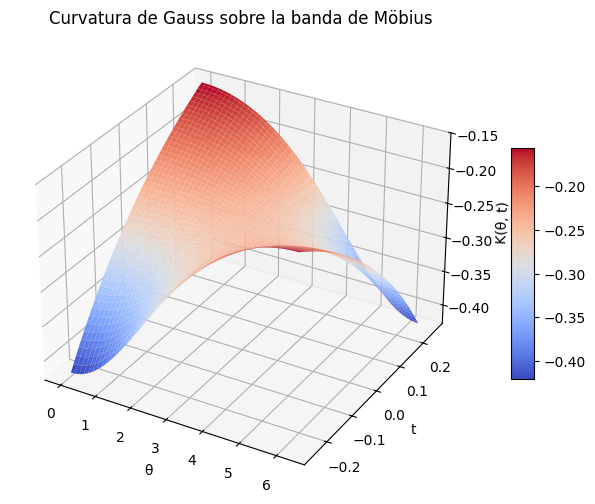

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# === Convertir la curvatura a función numérica
K_func = sp.lambdify((theta, t), K_simplified, 'numpy')

# === Crear malla de evaluación
theta_vals = np.linspace(0, 2*np.pi, 200)
t_vals = np.linspace(-0.25, 0.25, 100)
TH, TT = np.meshgrid(theta_vals, t_vals)

# === Evaluar K sobre la malla
K_vals = K_func(TH, TT)

# === Gráfico en 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(TH, TT, K_vals, cmap='coolwarm', edgecolor='none')
ax.set_title("Curvatura de Gauss sobre la banda de Möbius")
ax.set_xlabel("θ")
ax.set_ylabel("t")
ax.set_zlabel("K(θ, t)")
fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()


### 🌐 Curvatura de Gauss en la banda de Möbius

La curvatura de Gauss $K(\theta, t)$ representa cómo se curva la superficie en cada punto. En el caso de la banda de Möbius:

- La curvatura **no es constante**, como lo es en superficies más regulares (ej. esfera).
- En la gráfica observamos que $K(\theta, t)$ es siempre **negativa**, reflejando una curvatura tipo "silla de montar" propia de superficies con torsión.
- La torsión global de la banda se traduce en una **curvatura variable** que depende tanto del ángulo $\theta$ como del ancho local $t$.

Este comportamiento es característico de superficies **no orientables** y con geometría compleja, donde el campo de vectores normales no puede ser definido globalmente de forma continua.


In [14]:
# Vector normal unitario previamente calculado
normal_vec = X_theta.cross(X_t)
normal_unit = normal_vec / normal_vec.norm()

# Evaluar en t = 0
N_t0 = normal_unit.subs(t, 0)

# Evaluar límites cuando theta → 0 y theta → 2π
N_theta0 = N_t0.subs(theta, 0).evalf()
N_theta2pi = N_t0.subs(theta, 2 * sp.pi).evalf()

print("Normal unitario en (theta → 0, t = 0):")
display(N_theta0)

print("Normal unitario en (theta → 2π, t = 0):")
display(N_theta2pi)


Normal unitario en (theta → 0, t = 0):


Matrix([
[   0],
[   0],
[-1.0]])

Normal unitario en (theta → 2π, t = 0):


Matrix([
[  0],
[  0],
[1.0]])

### 🚩 Evaluación del campo normal – Orientabilidad

Evaluamos el vector normal unitario $\hat{N}(\theta, t)$ sobre la línea central de la banda ($t = 0$). Al comparar:

$$
\hat{N}(0, 0) = \begin{bmatrix} 0 \\ 0 \\ -1 \end{bmatrix}, \quad 
\hat{N}(2\pi, 0) = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}
$$

vemos que la dirección del vector cambia completamente al recorrer una vuelta completa en $\theta$.

---

Este resultado confirma que **no es posible definir un campo normal continuo en toda la banda**, lo cual implica que la banda de Möbius es:

> **Una superficie no orientable.**

Este comportamiento es característico de superficies con torsión global como la Möbius, que no pueden dividirse en "dos caras" coherentes como sucede con una esfera o un cilindro.
